# CNN1: детерминированный шум через tent map + компромиссная архитектура + test ≈ 100k

Это версия ноутбука для CNN1, где вместо удваивающего отображения используется **тент-отображение**:

\[
\eta_{t+1}=1-2|\eta_t-1/2|,
\qquad
z_t=F^{-1}_{trunc}(\eta_t).
\]

Сохраняем:

- усечённый шум с параметром `A_TRUNC = 3.0`, то есть \(z_t\in[-3,3]\);
- задачу CNN1: по ряду длины 59 классифицировать \(k\in\{1,2,3\}\);
- компромиссную архитектуру `Conv + BatchNorm + MaxPool`;
- 3 входных канала: сам ряд, первая разность, модуль первой разности.

Главное отличие от версии с doubling map:

- генератор базы заменён с \(\eta_{t+1}=2\eta_t\mod 1\) на tent map;
- всё остальное оставлено максимально синхронизированным: те же \(k\), \(n\), длина ряда, объёмы train/test, фильтры и архитектура.

Комбинации балансируются по парам `(k, n)`, где `k ∈ {1,2,3}`, `n ∈ {5,20,100,1000}`.


In [1]:

# ============================================================
# 0. Imports and basic setup
# ============================================================

import os
import random
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Автоматически используем GPU в Colab, если он есть. Локально без CUDA будет CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch version:", torch.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cpu
Torch version: 2.11.0+cpu


C:\Users\barna\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Настройки

По умолчанию test set получается около 100k:

\[
3\cdot 4\cdot 8334 = 100008.
\]

Если запускаешь локально на слабом ноутбуке и генерация/обучение слишком долгие, временно уменьши:

```python
TRAIN_PER_COMBO = 2000
TEST_PER_COMBO = 2000
```

Но для финального эксперимента оставь `TEST_PER_COMBO = 8334`.


In [2]:

# ============================================================
# 1. Experiment config
# ============================================================

SERIES_LENGTH = 59
A_TRUNC = 3.0
BURN_IN = 0

# Детерминированный шум через tent map: R(eta)=1-2|eta-1/2|.
# 2048 сильно больше максимального числа внутренних шагов: 59 * max(k) = 177.
ETA_BITS = 2048

K_VALUES = (1, 2, 3)
N_VALUES = (5, 20, 100, 1000)
COMBOS = [(k, n) for k in K_VALUES for n in N_VALUES]

# Размеры split-ов. 12 combo = 3 k * 4 n.
TRAIN_PER_COMBO = 10000   # 12 * 10000 = 120000 train rows
TEST_PER_COMBO = 8334     # 12 * 8334  = 100008 test rows

N_TRAIN = TRAIN_PER_COMBO * len(COMBOS)
N_TEST = TEST_PER_COMBO * len(COMBOS)

# Параметры модели выбираем внутри чуть обрезанного квадрата, чтобы реже ловить граничные артефакты.
PHI_STAR_RANGE = (0.06, 0.94)
OMEGA_RANGE = (0.06, 0.94)

# Пул допустимых параметров: сначала отбираем пары, где T(phi) не вылетает за [0,1] на сетке.
PARAM_POOL_SIZE = 60000
PARAM_POOL_BATCH = 5000
PARAM_GRID_SIZE = 512

# Численная обработка редких вылетов phi после добавления шума.
# При True: phi проецируется на [0,1], но ряды с большим числом проекций отбрасываются.
# При False: весь ряд отбрасывается сразу при первом вылете.
CLIP_TO_UNIT = True
MAX_CLIP_COUNT = 3

# Фильтр почти константных рядов. Если данных набирается очень долго, поставь 1e-4.
MIN_SERIES_STD = 5e-4

# 3 канала: row, diff(row), abs(diff(row)).
USE_EXTRA_CHANNELS = True

# Для 100k test оценка каждой эпохи тяжелее, поэтому batch побольше.
BATCH_SIZE = 256
EPOCHS = 25
LR = 3e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 10
DROPOUT = 0.10

NUM_WORKERS = 0  # безопасно для Windows/Jupyter; в Colab можно попробовать 2
PIN_MEMORY = (device.type == "cuda")

SAVE_DATA_ARRAYS = False  # True, если хочешь сохранить X/y на диск; файлы будут большими.
SAVE_DIR = "outputs_cnn1_tent_compromise_test100k"
os.makedirs(SAVE_DIR, exist_ok=True)

config = dict(
    NOISE_GENERATOR="tent_map",
    SERIES_LENGTH=SERIES_LENGTH,
    A_TRUNC=A_TRUNC,
    BURN_IN=BURN_IN,
    ETA_BITS=ETA_BITS,
    K_VALUES=K_VALUES,
    N_VALUES=N_VALUES,
    TRAIN_PER_COMBO=TRAIN_PER_COMBO,
    TEST_PER_COMBO=TEST_PER_COMBO,
    N_TRAIN=N_TRAIN,
    N_TEST=N_TEST,
    PHI_STAR_RANGE=PHI_STAR_RANGE,
    OMEGA_RANGE=OMEGA_RANGE,
    PARAM_POOL_SIZE=PARAM_POOL_SIZE,
    CLIP_TO_UNIT=CLIP_TO_UNIT,
    MAX_CLIP_COUNT=MAX_CLIP_COUNT,
    MIN_SERIES_STD=MIN_SERIES_STD,
    BATCH_SIZE=BATCH_SIZE,
    EPOCHS=EPOCHS,
    LR=LR,
    WEIGHT_DECAY=WEIGHT_DECAY,
    PATIENCE=PATIENCE,
    DROPOUT=DROPOUT,
    USE_EXTRA_CHANNELS=USE_EXTRA_CHANNELS,
)

with open(os.path.join(SAVE_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("N_TRAIN:", N_TRAIN)
print("N_TEST:", N_TEST)
print("COMBOS:", COMBOS)
print("BATCH_SIZE:", BATCH_SIZE)
print("SAVE_DIR:", SAVE_DIR)


N_TRAIN: 120000
N_TEST: 100008
COMBOS: [(1, 5), (1, 20), (1, 100), (1, 1000), (2, 5), (2, 20), (2, 100), (2, 1000), (3, 5), (3, 20), (3, 100), (3, 1000)]
BATCH_SIZE: 256
SAVE_DIR: outputs_cnn1_tent_compromise_test100k


## 2. Модельные функции

Используются функции исходной модели:

\[
b=(1-\omega)\left(\frac{1-\phi^*}{\phi^*}\right)^2,
\]

\[
T(\phi)=\frac{|\phi(1-\phi)|}{\sqrt{b\phi^2+\omega(1-\phi)^2}},
\]

\[
\sigma_n(\phi)=
\frac{b\phi^3\sqrt{1-\phi^2}}
{\sqrt n\left(b\phi^2+\omega(1-\phi)^2\right)^{3/2}}.
\]


In [3]:

# ============================================================
# 2. Model functions
# ============================================================

def b_from_phi_star_omega(phi_star, omega):
    phi_star = np.asarray(phi_star)
    omega = np.asarray(omega)
    return (1.0 - omega) * ((1.0 - phi_star) / phi_star) ** 2


def T_map(phi, phi_star, omega):
    b = b_from_phi_star_omega(phi_star, omega)
    denom = np.sqrt(b * phi**2 + omega * (1.0 - phi) ** 2 + 1e-12)
    return np.abs(phi * (1.0 - phi)) / denom


def sigma_map(phi, phi_star, omega, n):
    b = b_from_phi_star_omega(phi_star, omega)
    q = np.maximum(1.0 - phi**2, 0.0)
    denom = (b * phi**2 + omega * (1.0 - phi) ** 2 + 1e-12) ** 1.5
    return (b * phi**3 * np.sqrt(q)) / (np.sqrt(n) * denom + 1e-12)


def truncated_normal_quantile(u, A=3.0):
    lo = norm.cdf(-A)
    hi = norm.cdf(A)
    return norm.ppf(lo + u * (hi - lo))


## 3. Пул допустимых параметров

Чтобы не тратить время на совсем плохие пары \((\phi^*,\omega)\), сначала строим пул параметров, для которых детерминированная часть \(T\) на сетке остаётся в \([0,1]\).

Это не гарантирует отсутствие вылетов после добавления шума, но сильно уменьшает число артефактов.


In [4]:

# ============================================================
# 3. Build admissible parameter pool
# ============================================================

def build_admissible_parameter_pool(
    pool_size=60000,
    phi_star_range=(0.06, 0.94),
    omega_range=(0.06, 0.94),
    grid_size=512,
    batch_size=5000,
    seed=42,
):
    rng = np.random.default_rng(seed)
    grid = np.linspace(1e-5, 1.0 - 1e-5, grid_size, dtype=np.float64)
    accepted_phi = []
    accepted_omega = []
    attempts = 0

    pbar = tqdm(total=pool_size, desc="Building admissible parameter pool", mininterval=2.0)

    while len(accepted_phi) < pool_size:
        phis = rng.uniform(*phi_star_range, size=batch_size)
        omegas = rng.uniform(*omega_range, size=batch_size)
        attempts += batch_size

        # vectorized check over grid: shape = batch x grid
        b = b_from_phi_star_omega(phis[:, None], omegas[:, None])
        phi_grid = grid[None, :]
        denom = np.sqrt(b * phi_grid**2 + omegas[:, None] * (1.0 - phi_grid) ** 2 + 1e-12)
        T_vals = np.abs(phi_grid * (1.0 - phi_grid)) / denom
        max_T = np.max(T_vals, axis=1)
        finite = np.all(np.isfinite(T_vals), axis=1)
        mask = finite & (max_T <= 1.0 + 1e-6)

        for ps, om in zip(phis[mask], omegas[mask]):
            accepted_phi.append(float(ps))
            accepted_omega.append(float(om))
            pbar.update(1)
            if len(accepted_phi) >= pool_size:
                break

    pbar.close()
    pool = pd.DataFrame({"phi_star": accepted_phi[:pool_size], "omega": accepted_omega[:pool_size]})
    print("Pool size:", len(pool))
    print("Raw parameter attempts:", attempts)
    return pool


t0 = time.time()
param_pool = build_admissible_parameter_pool(
    pool_size=PARAM_POOL_SIZE,
    phi_star_range=PHI_STAR_RANGE,
    omega_range=OMEGA_RANGE,
    grid_size=PARAM_GRID_SIZE,
    batch_size=PARAM_POOL_BATCH,
    seed=SEED,
)
print("Pool build time, sec:", round(time.time() - t0, 2))
display(param_pool.head())
param_pool.to_csv(os.path.join(SAVE_DIR, "parameter_pool.csv"), index=False)


Building admissible parameter pool: 100%|█████████████████████████████████████| 60000/60000 [00:00<00:00, 82577.88it/s]

Pool size: 60000
Raw parameter attempts: 70000
Pool build time, sec: 0.75


,phi_star,omega
0,0.741081,0.251971
1,0.446213,0.643376
2,0.815566,0.734838
3,0.673684,0.206640
4,0.142876,0.098595


## 4. Генерация детерминированного шума

Внутри каждого ряда случайно выбирается только начальное \(\eta_0\). После этого шум полностью детерминированный:

\[
\eta_{t+1}=1-2|\eta_t-1/2|,
\qquad
z_t=F^{-1}_{trunc}(\eta_t).
\]

Чтобы tent map не схлопывался из-за float-точности, \(\eta\) хранится как большое целое с `ETA_BITS` битами.


eta0 example: 0.531842773501904
z min/max: -2.744614362716675 2.8494856357574463
z mean/std: 0.0012167692184448242 0.9913176894187927


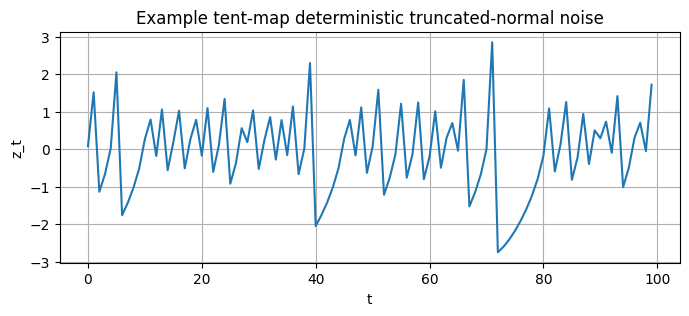

In [5]:

# ============================================================
# 4. Deterministic chaotic noise via tent map
# ============================================================

def _random_eta_state(rng, bits=2048):
    """Random initial state for eta in fixed-point representation.

    eta = state / 2**bits. State is made odd and kept away from exact dyadic
    boundary points, so the finite-precision tent map does not collapse too early.
    """
    n_bytes = (bits + 7) // 8
    mask = (1 << bits) - 1
    state = 0
    while state == 0 or state == mask:
        raw = rng.integers(0, 256, size=n_bytes, dtype=np.uint8).tobytes()
        state = int.from_bytes(raw, byteorder="big") & mask
    # Odd states avoid exact 1/2 and other simple dyadic boundary cases.
    state |= 1
    state &= mask
    if state == 0:
        state = 1
    return state


def _state_to_unit_float(state, bits=2048):
    """Convert fixed-point eta state to float in (0,1) using top 53 bits."""
    if bits >= 53:
        top = state >> (bits - 53)
        u = (top + 0.5) / float(1 << 53)
    else:
        u = (state + 0.5) / float(1 << bits)
    return float(np.clip(u, 1e-12, 1.0 - 1e-12))


def _tent_step_state(state, bits=2048):
    """One fixed-point step of the tent map R(u)=1-2|u-1/2|.

    With M=2**bits and u=state/M:
      if u < 1/2:  u' = 2u
      if u >=1/2:  u' = 2(1-u)
    The result is represented again as an integer state in [0, M).
    """
    M = 1 << bits
    half = 1 << (bits - 1)
    if state < half:
        new_state = state << 1
    else:
        new_state = (M - state) << 1

    # Keep inside [0, M). Hitting exactly M corresponds to u=1, which maps to 0;
    # this can only happen at exact dyadic boundary states, but we guard anyway.
    if new_state >= M:
        new_state = M - 1
    if new_state <= 0:
        new_state = 1
    return new_state


def make_tent_noise(total_steps, A=3.0, rng=None, bits=2048):
    """Generate deterministic truncated-normal noise using the tent map.

    eta_{t+1} = 1 - 2|eta_t - 1/2|,
    z_t = F^{-1}_{trunc}(eta_t), where F^{-1}_{trunc} is the quantile of
    the standard normal distribution truncated to [-A, A].
    """
    if rng is None:
        rng = np.random.default_rng()

    if total_steps >= bits:
        raise ValueError(
            f"ETA_BITS={bits} is too small for total_steps={total_steps}. Increase ETA_BITS."
        )

    state = _random_eta_state(rng, bits=bits)
    eta0_float = _state_to_unit_float(state, bits=bits)

    u_values = np.empty(total_steps, dtype=np.float64)
    for t in range(total_steps):
        u_values[t] = _state_to_unit_float(state, bits=bits)
        state = _tent_step_state(state, bits=bits)

    z_values = truncated_normal_quantile(u_values, A=A)
    return z_values.astype(np.float32), eta0_float


# Быстрая проверка шума.
rng_check = np.random.default_rng(SEED)
z_check, eta0_check = make_tent_noise(200, A=A_TRUNC, rng=rng_check, bits=ETA_BITS)
print("eta0 example:", eta0_check)
print("z min/max:", float(z_check.min()), float(z_check.max()))
print("z mean/std:", float(z_check.mean()), float(z_check.std()))
plt.figure(figsize=(8, 3))
plt.plot(z_check[:100])
plt.title("Example tent-map deterministic truncated-normal noise")
plt.xlabel("t")
plt.ylabel("z_t")
plt.grid(True)
plt.show()


## 5. Генерация train/test

Генерируем train и test **отдельно**, без `train_test_split`.

Так проще обеспечить test около 100k и балансировку по всем парам `(k,n)`.


In [6]:

# ============================================================
# 5. Synthetic data generation
# ============================================================

def simulate_series(
    phi_star,
    omega,
    n,
    k,
    length=59,
    A=3.0,
    burn_in=0,
    rng=None,
    eta_bits=2048,
    clip_to_unit=True,
):
    if rng is None:
        rng = np.random.default_rng()

    total_steps = burn_in + length * k
    phi = rng.uniform(0.0, 1.0)
    z_values, eta0 = make_tent_noise(total_steps, A=A, rng=rng, bits=eta_bits)

    values = []
    clip_count = 0
    out_of_bounds_count = 0

    for t in range(total_steps):
        phi_next = T_map(phi, phi_star, omega) + sigma_map(phi, phi_star, omega, n) * z_values[t]

        if not np.isfinite(phi_next):
            return None, False, clip_count, out_of_bounds_count, eta0

        if (phi_next < 0.0) or (phi_next > 1.0):
            out_of_bounds_count += 1
            if clip_to_unit:
                phi_next = np.clip(phi_next, 0.0, 1.0)
                clip_count += 1
            else:
                return None, False, clip_count, out_of_bounds_count, eta0

        phi = float(phi_next)

        if t >= burn_in:
            values.append(phi)

    values = np.asarray(values, dtype=np.float32)
    observed = values[::k][:length]

    if observed.shape[0] != length:
        return None, False, clip_count, out_of_bounds_count, eta0
    if not np.all(np.isfinite(observed)):
        return None, False, clip_count, out_of_bounds_count, eta0

    return observed.astype(np.float32), True, clip_count, out_of_bounds_count, eta0


def make_cnn_input_from_series(series, mean=None, std=None, use_extra_channels=True):
    # This helper is used only after mean/std are known; generation stores raw series.
    Xs = (series - mean) / (std + 1e-8)
    if not use_extra_channels:
        return Xs[:, None, :].astype(np.float32)
    d1 = np.diff(Xs, axis=1, prepend=Xs[:, :1])
    abs_d1 = np.abs(d1)
    return np.stack([Xs, d1, abs_d1], axis=1).astype(np.float32)


def generate_balanced_dataset(
    samples_per_combo,
    split_name,
    param_pool,
    length=59,
    A=3.0,
    k_values=(1,2,3),
    n_values=(5,20,100,1000),
    burn_in=0,
    eta_bits=2048,
    min_series_std=5e-4,
    max_clip_count=3,
    clip_to_unit=True,
    seed=42,
):
    rng = np.random.default_rng(seed)
    combos = [(k, n) for k in k_values for n in n_values]
    target_total = samples_per_combo * len(combos)

    X = np.empty((target_total, length), dtype=np.float32)
    y_k = np.empty(target_total, dtype=np.int64)
    y_params = np.empty((target_total, 2), dtype=np.float32)
    meta_rows = []

    idx = 0
    attempts = 0
    rejected_bad = 0
    rejected_flat = 0
    rejected_clip = 0
    total_clip_count = 0

    pbar = tqdm(total=target_total, desc=f"Generating {split_name}", mininterval=2.0, miniters=500)

    for k, n_current in combos:
        got_for_combo = 0
        while got_for_combo < samples_per_combo:
            attempts += 1

            pool_idx = int(rng.integers(0, len(param_pool)))
            phi_star = float(param_pool.iloc[pool_idx]["phi_star"])
            omega = float(param_pool.iloc[pool_idx]["omega"])

            series, ok, clip_count, oob_count, eta0 = simulate_series(
                phi_star=phi_star,
                omega=omega,
                n=n_current,
                k=k,
                length=length,
                A=A,
                burn_in=burn_in,
                rng=rng,
                eta_bits=eta_bits,
                clip_to_unit=clip_to_unit,
            )

            if not ok:
                rejected_bad += 1
                continue

            if clip_count > max_clip_count:
                rejected_clip += 1
                continue

            s_std = float(np.std(series))
            if s_std < min_series_std:
                rejected_flat += 1
                continue

            X[idx] = series
            y_k[idx] = k - 1
            y_params[idx] = [phi_star, omega]
            meta_rows.append({
                "split": split_name,
                "phi_star": phi_star,
                "omega": omega,
                "n": int(n_current),
                "k": int(k),
                "eta0": float(eta0),
                "clip_count": int(clip_count),
                "out_of_bounds_count": int(oob_count),
                "series_std": s_std,
            })

            idx += 1
            got_for_combo += 1
            total_clip_count += clip_count
            pbar.update(1)

            if idx % 10000 == 0:
                pbar.set_postfix({
                    "attempts": attempts,
                    "bad": rejected_bad,
                    "flat": rejected_flat,
                    "clip": rejected_clip,
                })

    pbar.close()

    meta = pd.DataFrame(meta_rows)

    # Перемешиваем split, чтобы test/train не были упорядочены по combo.
    perm = rng.permutation(target_total)
    X = X[perm]
    y_k = y_k[perm]
    y_params = y_params[perm]
    meta = meta.iloc[perm].reset_index(drop=True)

    print(f"\n{split_name} dataset:")
    print("X:", X.shape)
    print("y_k:", y_k.shape)
    print("y_params:", y_params.shape)
    print("meta:", meta.shape)
    print("attempts:", attempts)
    print("rejected_bad:", rejected_bad)
    print("rejected_flat:", rejected_flat)
    print("rejected_clip:", rejected_clip)
    print("total_clip_count:", total_clip_count)

    return X, y_k, y_params, meta


In [7]:

# ============================================================
# 6. Generate train and test sets
# ============================================================

t0 = time.time()

X_train_raw, y_train, y_params_train, meta_train = generate_balanced_dataset(
    samples_per_combo=TRAIN_PER_COMBO,
    split_name="train",
    param_pool=param_pool,
    length=SERIES_LENGTH,
    A=A_TRUNC,
    k_values=K_VALUES,
    n_values=N_VALUES,
    burn_in=BURN_IN,
    eta_bits=ETA_BITS,
    min_series_std=MIN_SERIES_STD,
    max_clip_count=MAX_CLIP_COUNT,
    clip_to_unit=CLIP_TO_UNIT,
    seed=SEED + 1,
)

X_test_raw, y_test, y_params_test, meta_test = generate_balanced_dataset(
    samples_per_combo=TEST_PER_COMBO,
    split_name="test",
    param_pool=param_pool,
    length=SERIES_LENGTH,
    A=A_TRUNC,
    k_values=K_VALUES,
    n_values=N_VALUES,
    burn_in=BURN_IN,
    eta_bits=ETA_BITS,
    min_series_std=MIN_SERIES_STD,
    max_clip_count=MAX_CLIP_COUNT,
    clip_to_unit=CLIP_TO_UNIT,
    seed=SEED + 2,
)

print("\nTotal generation time, sec:", round(time.time() - t0, 2))

print("\nTrain k counts:")
print(pd.Series(y_train + 1).value_counts().sort_index())
print("\nTest k counts:")
print(pd.Series(y_test + 1).value_counts().sort_index())

print("\nTrain n counts:")
print(meta_train["n"].value_counts().sort_index())
print("\nTest n counts:")
print(meta_test["n"].value_counts().sort_index())

meta_train.to_csv(os.path.join(SAVE_DIR, "meta_train.csv"), index=False)
meta_test.to_csv(os.path.join(SAVE_DIR, "meta_test.csv"), index=False)

if SAVE_DATA_ARRAYS:
    np.save(os.path.join(SAVE_DIR, "X_train_raw.npy"), X_train_raw)
    np.save(os.path.join(SAVE_DIR, "X_test_raw.npy"), X_test_raw)
    np.save(os.path.join(SAVE_DIR, "y_train.npy"), y_train)
    np.save(os.path.join(SAVE_DIR, "y_test.npy"), y_test)
    np.save(os.path.join(SAVE_DIR, "y_params_train.npy"), y_params_train)
    np.save(os.path.join(SAVE_DIR, "y_params_test.npy"), y_params_test)


Generating train: 100%|████████████| 120000/120000 [10:53<00:00, 183.50it/s, attempts=124353, bad=0, flat=4353, clip=0]



train dataset:
X: (120000, 59)
y_k: (120000,)
y_params: (120000, 2)
meta: (120000, 9)
attempts: 124353
rejected_bad: 0
rejected_flat: 4353
rejected_clip: 0
total_clip_count: 39537


Generating test: 100%|█████████████| 100008/100008 [09:26<00:00, 176.39it/s, attempts=103686, bad=0, flat=3686, clip=0]



test dataset:
X: (100008, 59)
y_k: (100008,)
y_params: (100008, 2)
meta: (100008, 9)
attempts: 103694
rejected_bad: 0
rejected_flat: 3686
rejected_clip: 0
total_clip_count: 32581

Total generation time, sec: 1221.45

Train k counts:
1    40000
2    40000
3    40000
Name: count, dtype: int64

Test k counts:
1    33336
2    33336
3    33336
Name: count, dtype: int64

Train n counts:
n
5       30000
20      30000
100     30000
1000    30000
Name: count, dtype: int64

Test n counts:
n
5       25002
20      25002
100     25002
1000    25002
Name: count, dtype: int64


## 6. Диагностика данных


==== train ====
X shape: (120000, 59)
X min/max: 0.0 1.0
Any NaN: False
Mean row std: 0.09916462749242783
Min row std: 0.0005065242876298726
Rows with std < MIN_SERIES_STD: 0

Class distribution:
1    0.333333
2    0.333333
3    0.333333
Name: proportion, dtype: float64

n distribution:
n
5       0.25
20      0.25
100     0.25
1000    0.25
Name: proportion, dtype: float64

clip_count describe:
count    120000.000000
mean          0.329475
std           0.470025
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: clip_count, dtype: float64

Mean series std by k:
     count      mean       std       min       25%       50%       75%  \
y                                                                        
1  40000.0  0.108858  0.093523  0.000546  0.028071  0.078916  0.174545   
2  40000.0  0.097503  0.084605  0.000507  0.026496  0.072042  0.149909   
3  40000.0  0.091133  0.079996  0.000607  0.026002  0.067285  0.135

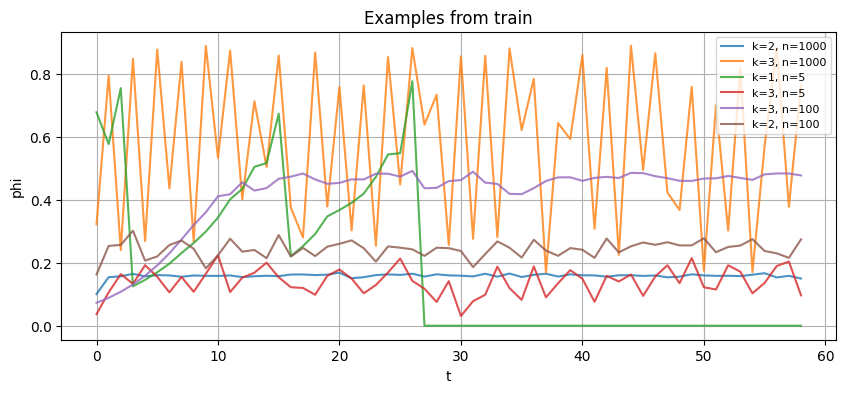

==== test ====
X shape: (100008, 59)
X min/max: 0.0 1.0
Any NaN: False
Mean row std: 0.09836709499359131
Min row std: 0.0005395307671278715
Rows with std < MIN_SERIES_STD: 0

Class distribution:
1    0.333333
2    0.333333
3    0.333333
Name: proportion, dtype: float64

n distribution:
n
5       0.25
20      0.25
100     0.25
1000    0.25
Name: proportion, dtype: float64

clip_count describe:
count    100008.000000
mean          0.325784
std           0.468669
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: clip_count, dtype: float64

Mean series std by k:
     count      mean       std       min       25%       50%       75%  \
y                                                                        
1  33336.0  0.108332  0.093204  0.000540  0.027840  0.078914  0.173125   
2  33336.0  0.096986  0.084509  0.000574  0.026580  0.070774  0.148871   
3  33336.0  0.089783  0.079124  0.000682  0.025574  0.065401  0.1330

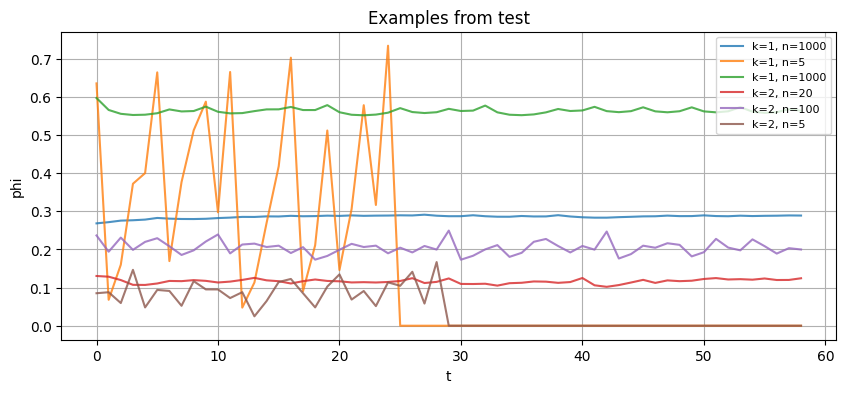

In [8]:

# ============================================================
# 7. Dataset diagnostics
# ============================================================

def check_dataset(X, y_k, meta, title="dataset", n_plot=6):
    print("====", title, "====")
    print("X shape:", X.shape)
    print("X min/max:", float(X.min()), float(X.max()))
    print("Any NaN:", bool(np.isnan(X).any()))
    print("Mean row std:", float(np.std(X, axis=1).mean()))
    print("Min row std:", float(np.std(X, axis=1).min()))
    print("Rows with std < MIN_SERIES_STD:", int((np.std(X, axis=1) < MIN_SERIES_STD).sum()))

    print("\nClass distribution:")
    print(pd.Series(y_k + 1).value_counts(normalize=True).sort_index())

    print("\nn distribution:")
    print(meta["n"].value_counts(normalize=True).sort_index())

    print("\nclip_count describe:")
    print(meta["clip_count"].describe())

    print("\nMean series std by k:")
    tmp = meta.copy()
    tmp["y"] = y_k + 1
    print(tmp.groupby("y")["series_std"].describe())

    plt.figure(figsize=(10, 4))
    for i in range(min(n_plot, len(X))):
        plt.plot(X[i], alpha=0.8, label=f"k={y_k[i]+1}, n={meta.iloc[i]['n']}")
    plt.title(f"Examples from {title}")
    plt.xlabel("t")
    plt.ylabel("phi")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

check_dataset(X_train_raw, y_train, meta_train, title="train")
check_dataset(X_test_raw, y_test, meta_test, title="test")


## 7. Входные каналы и DataLoader

Стандартизация считается **только по train set** и потом применяется к train и test.


In [9]:

# ============================================================
# 8. Prepare CNN inputs and DataLoaders
# ============================================================

train_mean = X_train_raw.mean()
train_std = X_train_raw.std() + 1e-8
print("train_mean:", float(train_mean))
print("train_std:", float(train_std))

X_train_used = make_cnn_input_from_series(X_train_raw, mean=train_mean, std=train_std, use_extra_channels=USE_EXTRA_CHANNELS)
X_test_used = make_cnn_input_from_series(X_test_raw, mean=train_mean, std=train_std, use_extra_channels=USE_EXTRA_CHANNELS)

IN_CHANNELS = X_train_used.shape[1]
print("X_train_used:", X_train_used.shape)
print("X_test_used:", X_test_used.shape)
print("IN_CHANNELS:", IN_CHANNELS)

train_ds = TensorDataset(
    torch.tensor(X_train_used, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)

test_ds = TensorDataset(
    torch.tensor(X_test_used, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long),
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))
print("Train batches per epoch:", len(train_loader))
print("Test batches:", len(test_loader))


train_mean: 0.2821013033390045
train_std: 0.25301074981689453
X_train_used: (120000, 3, 59)
X_test_used: (100008, 3, 59)
IN_CHANNELS: 3
Train size: 120000
Test size: 100008
Train batches per epoch: 469
Test batches: 391


## 8. Компромиссная CNN1

Это та же идея, что в предыдущем рабочем компромиссном ноутбуке:

- `Conv1d + BatchNorm1d + ReLU + MaxPool1d`;
- финальное `AdaptiveAvgPool1d(1)`;
- выход — сырые logits без `softmax`, потому что используется `CrossEntropyLoss`.


In [10]:

# ============================================================
# 9. CNN1 compromise architecture
# ============================================================

class CNN1Compromise(nn.Module):
    def __init__(self, in_channels=3, n_classes=3, dropout=0.10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),       # 59 -> 29

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),       # 29 -> 14

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),       # 14 -> 7

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                     # 7 -> 1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_shapes(model, in_channels):
    model_cpu = model.to("cpu")
    x = torch.zeros(1, in_channels, SERIES_LENGTH)
    print("input:", tuple(x.shape))
    for layer in model_cpu.features:
        x = layer(x)
        if isinstance(layer, (nn.Conv1d, nn.MaxPool1d, nn.AdaptiveAvgPool1d)):
            print(layer.__class__.__name__, tuple(x.shape))
    y = model_cpu.classifier(x)
    print("output:", tuple(y.shape))
    model.to(device)

cnn1_tmp = CNN1Compromise(in_channels=IN_CHANNELS, n_classes=3, dropout=DROPOUT).to(device)
print("CNN1 trainable params:", count_params(cnn1_tmp))
show_shapes(cnn1_tmp, IN_CHANNELS)
del cnn1_tmp


CNN1 trainable params: 150019
input: (1, 3, 59)
Conv1d (1, 64, 59)
MaxPool1d (1, 64, 29)
Conv1d (1, 128, 29)
MaxPool1d (1, 128, 14)
Conv1d (1, 128, 14)
MaxPool1d (1, 128, 7)
Conv1d (1, 128, 7)
AdaptiveAvgPool1d (1, 128, 1)
output: (1, 3)


## 9. Обучение

Для test около 100k оценка после каждой эпохи занимает заметное время. Это нормально.

В истории сохраняется лучший checkpoint по `test_acc`; в конце он автоматически загружается обратно в модель.


In [11]:

# ============================================================
# 10. Training/evaluation functions
# ============================================================

def move_to_device(xb, yb):
    xb = xb.to(device, non_blocking=PIN_MEMORY)
    yb = yb.to(device, non_blocking=PIN_MEMORY)
    return xb, yb


def train_one_epoch(model, loader, optimizer, criterion, epoch, epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"train {epoch}/{epochs}", mininterval=5.0, miniters=20)

    for xb, yb in pbar:
        xb, yb = move_to_device(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += bs

        pbar.set_postfix({"loss": total_loss / total, "acc": correct / total})

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_metrics(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = move_to_device(xb, yb)
        logits = model(xb)
        loss = criterion(logits, yb)

        bs = xb.size(0)
        total_loss += loss.item() * bs
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += bs

    return total_loss / total, correct / total


@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    for xb, yb in tqdm(loader, desc="predict", mininterval=2.0):
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_pred)


def train_cnn1(
    model,
    train_loader,
    test_loader,
    epochs=45,
    lr=3e-3,
    weight_decay=1e-5,
    checkpoint_name="cnn1_compromise_tent_test100k_best.pt",
    patience=10,
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    best_acc = -1.0
    best_epoch = 0
    wait = 0
    best_path = os.path.join(SAVE_DIR, checkpoint_name)

    for epoch in range(1, epochs + 1):
        t_epoch = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, epochs)
        test_loss, test_acc = evaluate_metrics(model, test_loader, criterion)
        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "lr": current_lr,
            "seconds": time.time() - t_epoch,
        }
        history.append(row)
        print(row)

        if test_acc > best_acc:
            best_acc = test_acc
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), best_path)
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping: нет улучшения {patience} эпох. Best epoch={best_epoch}, best_acc={best_acc:.4f}")
            break

    model.load_state_dict(torch.load(best_path, map_location=device))
    history = pd.DataFrame(history)
    history_path = os.path.join(SAVE_DIR, "cnn1_history_compromise_tent_test100k.csv")
    history.to_csv(history_path, index=False)

    print("Best test_acc:", best_acc)
    print("Best epoch:", best_epoch)
    print("Best checkpoint loaded:", best_path)
    print("History saved to:", history_path)
    return history


## 10. Optional overfit-check

Обычно выключен, потому что при большом датасете мы сразу запускаем основное обучение.

Включи только если accuracy снова стоит около 0.33.


In [12]:

# ============================================================
# 11. Optional overfit check
# ============================================================

RUN_OVERFIT_CHECK = False

if RUN_OVERFIT_CHECK:
    small_per_class = 20
    idxs = []
    for cls in [0, 1, 2]:
        idxs.append(np.where(y_train == cls)[0][:small_per_class])
    small_idx = np.concatenate(idxs)

    X_small = X_train_used[small_idx]
    y_small = y_train[small_idx]

    small_ds = TensorDataset(
        torch.tensor(X_small, dtype=torch.float32),
        torch.tensor(y_small, dtype=torch.long),
    )
    small_loader = DataLoader(small_ds, batch_size=16, shuffle=True, num_workers=0)

    overfit_model = CNN1Compromise(in_channels=IN_CHANNELS, n_classes=3, dropout=0.0).to(device)
    print("Overfit model params:", count_params(overfit_model))

    hist_overfit = train_cnn1(
        overfit_model,
        small_loader,
        small_loader,
        epochs=120,
        lr=3e-3,
        weight_decay=0.0,
        checkpoint_name="cnn1_overfit_compromise_tent_test100k.pt",
        patience=30,
    )

    display(hist_overfit.tail())


## 11. Основное обучение CNN1


In [13]:

# ============================================================
# 12. Main CNN1 training
# ============================================================

cnn1 = CNN1Compromise(in_channels=IN_CHANNELS, n_classes=3, dropout=DROPOUT).to(device)
print("CNN1 trainable params:", count_params(cnn1))

t0 = time.time()
history = train_cnn1(
    cnn1,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    checkpoint_name="cnn1_compromise_tent_test100k_best.pt",
    patience=PATIENCE,
)
print("Total training time, sec:", round(time.time() - t0, 2))

display(history.tail())


CNN1 trainable params: 150019


train 1/25: 100%|██████████████████████████████████████████████| 469/469 [00:31<00:00, 14.92it/s, loss=0.715, acc=0.62]


{'epoch': 1, 'train_loss': 0.714728608194987, 'train_acc': 0.6198916666666666, 'test_loss': 0.6174552463958782, 'test_acc': 0.6816854651627869, 'lr': 0.003, 'seconds': 39.92556047439575}


train 2/25: 100%|█████████████████████████████████████████████| 469/469 [00:30<00:00, 15.13it/s, loss=0.566, acc=0.708]


{'epoch': 2, 'train_loss': 0.5655521067937215, 'train_acc': 0.7079666666666666, 'test_loss': 0.5218211930495779, 'test_acc': 0.7376109911207104, 'lr': 0.003, 'seconds': 39.678614377975464}


...

train 24/25: 100%|████████████████████████████████████████████| 469/469 [00:34<00:00, 13.71it/s, loss=0.224, acc=0.891]


{'epoch': 24, 'train_loss': 0.22449677562713624, 'train_acc': 0.8914333333333333, 'test_loss': 0.3402820269176173, 'test_acc': 0.8544316454683625, 'lr': 0.003, 'seconds': 43.38288879394531}


train 25/25: 100%|████████████████████████████████████████████| 469/469 [00:32<00:00, 14.26it/s, loss=0.223, acc=0.892]


{'epoch': 25, 'train_loss': 0.22256642978986105, 'train_acc': 0.892125, 'test_loss': 0.35797386980087276, 'test_acc': 0.8577813774898008, 'lr': 0.003, 'seconds': 41.75936985015869}
Best test_acc: 0.8577813774898008
Best epoch: 25
Best checkpoint loaded: outputs_cnn1_tent_compromise_test100k\cnn1_compromise_tent_test100k_best.pt
History saved to: outputs_cnn1_tent_compromise_test100k\cnn1_history_compromise_tent_test100k.csv
Total training time, sec: 1049.75


,epoch,train_loss,train_acc,test_loss,test_acc,lr,seconds
20,21,0.237996,0.884850,0.349034,0.846812,0.003,39.836404
21,22,0.230678,0.888317,0.963619,0.786397,0.003,39.783605
22,23,0.227486,0.890508,0.394742,0.831044,0.003,40.797566
23,24,0.224497,0.891433,0.340282,0.854432,0.003,43.382889
24,25,0.222566,0.892125,0.357974,0.857781,0.003,41.759370


## 12. Графики и финальная оценка


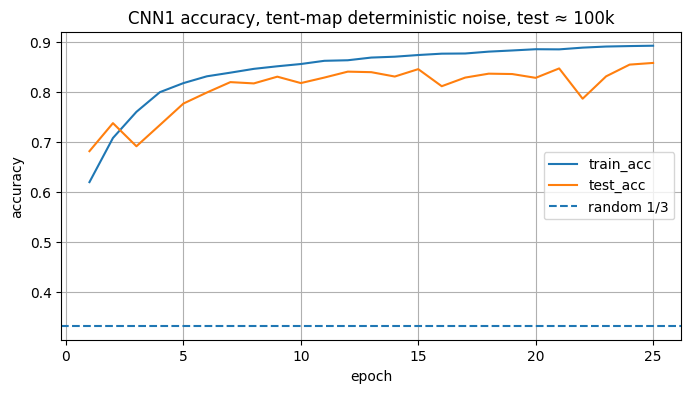

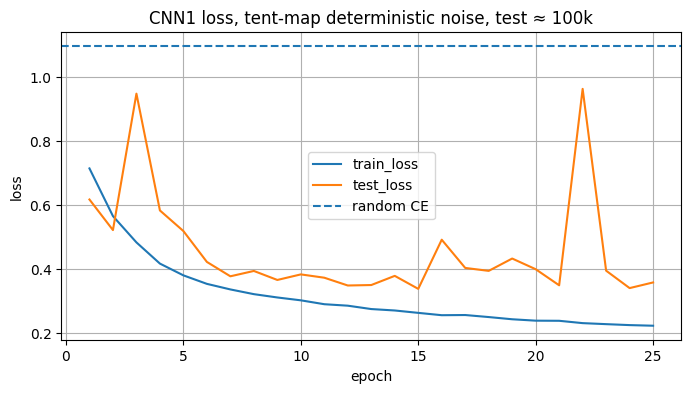

Final loaded-best test_loss: 0.35797386980087276
Final loaded-best test_acc: 0.8577813774898008


In [14]:

# ============================================================
# 13. Plots and final evaluation
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(history["epoch"], history["train_acc"], label="train_acc")
plt.plot(history["epoch"], history["test_acc"], label="test_acc")
plt.axhline(1/3, linestyle="--", label="random 1/3")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("CNN1 accuracy, tent-map deterministic noise, test ≈ 100k")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "cnn1_accuracy_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["epoch"], history["train_loss"], label="train_loss")
plt.plot(history["epoch"], history["test_loss"], label="test_loss")
plt.axhline(-np.log(1/3), linestyle="--", label="random CE")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("CNN1 loss, tent-map deterministic noise, test ≈ 100k")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "cnn1_loss_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

criterion = nn.CrossEntropyLoss()
final_loss, final_acc = evaluate_metrics(cnn1, test_loader, criterion)
print("Final loaded-best test_loss:", final_loss)
print("Final loaded-best test_acc:", final_acc)


## 13. Confusion matrix в стиле статьи


predict: 100%|███████████████████████████████████████████████████████████████████████| 391/391 [00:08<00:00, 44.95it/s]


Confusion matrix counts, rows=true k, cols=pred k
[[31668  1140   528]
 [ 1594 25712  6030]
 [  879  4052 28405]]

Classification report
              precision    recall  f1-score   support

           1       0.93      0.95      0.94     33336
           2       0.83      0.77      0.80     33336
           3       0.81      0.85      0.83     33336

    accuracy                           0.86    100008
   macro avg       0.86      0.86      0.86    100008
weighted avg       0.86      0.86      0.86    100008


Normalized confusion matrix:
[[0.949964   0.03419726 0.01583873]
 [0.04781617 0.7712983  0.18088553]
 [0.02636789 0.12155028 0.85208183]]
accuracy=0.8578; misclass=0.1422


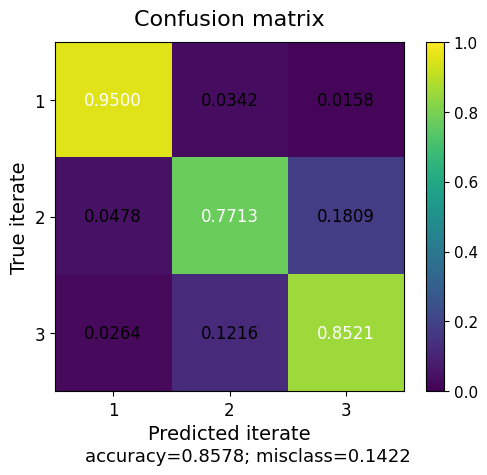

Saved confusion matrix to: outputs_cnn1_tent_compromise_test100k\cnn1_confusion_matrix_tent_test100k.png


In [15]:

# ============================================================
# 14. Confusion matrix article-style
# ============================================================

y_true, y_pred = predict_all(cnn1, test_loader)

cm = confusion_matrix(y_true + 1, y_pred + 1, labels=[1, 2, 3])
print("Confusion matrix counts, rows=true k, cols=pred k")
print(cm)
print("\nClassification report")
print(classification_report(y_true + 1, y_pred + 1, labels=[1, 2, 3]))

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
accuracy = np.trace(cm) / np.sum(cm)
misclass = 1.0 - accuracy

print("\nNormalized confusion matrix:")
print(cm_norm)
print(f"accuracy={accuracy:.4f}; misclass={misclass:.4f}")

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm_norm, interpolation="nearest", vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=11)

classes = ["1", "2", "3"]
ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(3))
ax.set_xticklabels(classes, fontsize=12)
ax.set_yticklabels(classes, fontsize=12)
ax.set_xlabel("Predicted iterate", fontsize=14)
ax.set_ylabel("True iterate", fontsize=14)
ax.set_title("Confusion matrix", fontsize=16, pad=12)

threshold = cm_norm.max() / 2.0
for i in range(3):
    for j in range(3):
        value = cm_norm[i, j]
        ax.text(
            j,
            i,
            f"{value:.4f}",
            ha="center",
            va="center",
            fontsize=12,
            color="white" if value > threshold else "black",
        )

fig.text(
    0.5,
    0.02,
    f"accuracy={accuracy:.4f}; misclass={misclass:.4f}",
    ha="center",
    fontsize=13,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig_path = os.path.join(SAVE_DIR, "cnn1_confusion_matrix_tent_test100k.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved confusion matrix to:", fig_path)


## 14. Что писать в дипломе про этот эксперимент

Можно формулировать так:

> Для дополнительной проверки робастности детерминированно-эргодической модификации была обучена CNN1 на синтетических рядах, где хаотический генератор шума задавался не удваивающим отображением, а тент-отображением
> \[
> \eta_{t+1}=1-2|\eta_t-1/2|.
> \]
> Далее последовательность \(\eta_t\) преобразовывалась в усечённый нормальный шум через квантильное преобразование. Архитектура CNN, параметры генерации данных и разбиение по классам \(k\in\{1,2,3\}\) были оставлены такими же, как в основном эксперименте, что позволяет сравнить влияние выбора хаотического генератора.

Если точность снова около 0.33:

1. включи `RUN_OVERFIT_CHECK = True`;
2. поставь `MIN_SERIES_STD = 1e-3`;
3. попробуй `N_VALUES = (20, 100, 1000)`;
4. увеличь `EPOCHS` до 60;
5. проверь, что `device` в Colab показывает `cuda`.
